In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
dataset = pd.read_csv('Mall_Customers.csv')


In [9]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [10]:
X = dataset.iloc[:, 2:5].values

In [11]:
X

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

In [12]:
from sklearn.cluster import AffinityPropagation
clusmodel = AffinityPropagation()
label = clusmodel.fit_predict(X)

In [13]:
label

array([ 2,  1,  2,  1,  2,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  2,
        1,  2,  1,  2,  1,  0,  1,  0,  1,  2,  1,  2,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  2,  1,  4,  1,  2,  3,  2,  3,  4,  3,  3,  3,  5,
        3,  3,  4,  5,  5,  5,  4,  3,  5,  4,  3,  4,  4,  4,  3,  5,  4,
        3,  3,  4,  5,  4,  4,  4,  3,  5,  5,  3,  5,  4,  5,  4,  5,  3,
        5,  4,  3,  3,  5,  4,  6,  5,  5,  6,  6,  5,  6,  5,  6,  6,  5,
        4,  6,  5,  6,  4,  5,  4,  4,  4,  6,  5,  6,  6,  6,  4,  5,  5,
        5,  6,  6,  7,  8,  6,  7,  9,  8,  9,  7,  9,  7,  6,  7,  9,  8,
        9,  7,  9,  7,  9,  8,  6,  8,  9,  8,  9,  7,  9,  8,  9,  8,  9,
        7,  9,  8,  9,  7,  9,  7,  9,  8,  9,  8,  9,  7,  9,  8,  9,  7,
        9,  7,  9,  8,  9,  8,  9,  7, 10, 11, 10, 11, 10, 11, 10, 11, 10,
       11, 10, 11, 10, 11, 10, 11, 10, 11, 10, 11, 10, 11], dtype=int64)

In [14]:
supervised=dataset

In [15]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [16]:
supervised['Cluster_group']=label

In [17]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,11
196,197,Female,45,126,28,10
197,198,Male,32,126,74,11
198,199,Male,32,137,18,10


In [18]:
supervised.to_csv("affinity_propogation_cluster.csv",index=False)

In [19]:
supervised.columns[3]

'Annual Income (k$)'

In [20]:
supervised.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster_group'],
      dtype='object')

C:\Anaconda\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


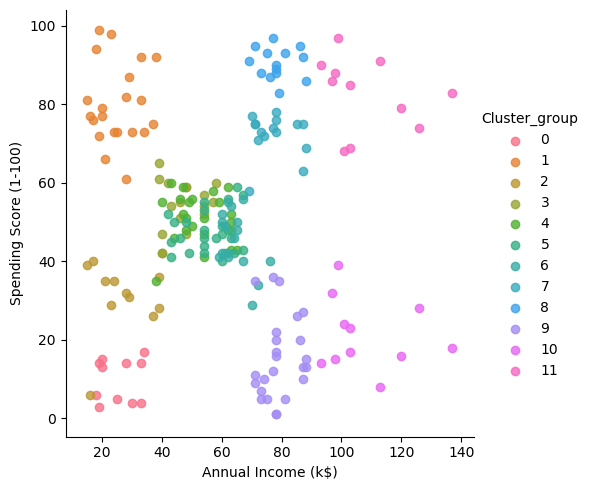

In [21]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True, legend_out=True)